# 利用全连接神经网络识别 MNIST 手写数字
=====================================================

本教程使用 Pytorch 构建一个多层全连接神经网络 FCNN, 将28*28的灰度手写数字图片分类为 0~9

学习目标：
 - 使用 torchvision 下载和加载 MNIST 数据集
 - 理解图像展平、全连接层和 ReLU 激活函数
 - 完成模型训练、测试与单张预测
 - 观察训练曲线和混淆矩阵

## 1、环境与实验配置

实验依赖下列 Python 库： torch torchvision matplotlib seaborn scikit-learn

MNIST 包含 60,000 张训练图片和 10,000 张测试图片，每张图片为单通道 28*28 像素，标签是对应的数字类别。 



本教程使用 Pytorch 构建一个多层全连接神经网络 FCNN, 将28*28的灰度手写数字图片分类为 0~9

学习目标：
 - 使用 torchvision 下载和加载 MNIST 数据集
 - 理解图像展平、全连接层和 ReLU 激活函数
 - 完成模型训练、测试与单张预测
 - 观察训练曲线和混淆矩阵

## 1、环境与实验配置

实验依赖下列 Python 库： torch torchvision matplotlib seaborn scikit-learn

MNIST 包含 60,000 张训练图片和 10,000 张测试图片，每张图片为单通道 28*28 像素，标签是对应的数字类别。 


In [4]:
# 下载所需的 Python 库
!pip install torch torchvision matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.13.0-cp314-cp314-win_amd64.whl.metadata (39 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 1.3/122.1 MB 4.8 MB/s eta 0:00:26
    --------------------------------------- 2.1/122.1 MB 4.3 MB/s eta 0:00:28
    --------------------------------------- 2.6/122.1 MB 4.2 MB/s eta 0:00:29
   - -------------------------------------- 3.1/122.1 MB 3.8 MB/s eta 0:00:32
   - -------

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

# 固定随机种子，使本教程的结果更容易复现
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 根据实验环境灵活设置在CPU或者GPU中训练、推理
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'当前使用的设备: {device}')

当前使用的设备: cpu


## 2. 下载并加载数据

ToTensor() 会把像素值从0~255转换到0~1；随后使用均值0.5、标准差0.5归一化
首次运行时，download=True会自动下载数据集到当前目录下的data文件夹


In [11]:
BATCH_SIZE = 64 # 批量大小

transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为张量
    transforms.Normalize((0.5,), (0.5,))  # 对图像进行归一化处理
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform) # 下载训练集
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform) # 下载测试集

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # 创建训练集数据加载器
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # 创建测试集数据加载器

print(f'训练集样本数量: {len(train_dataset)}')
print(f'测试集样本数量: {len(test_dataset)}')

训练集样本数量: 60000
测试集样本数量: 10000


批次数据形状: torch.Size([64, 1, 28, 28])
批次标签形状: torch.Size([64])


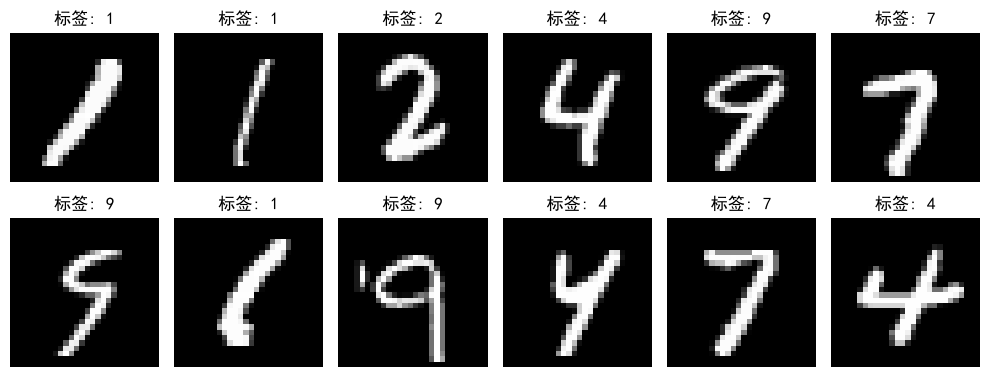

In [14]:

# 查看一个批次的数据形状及部分样本
images, labels = next(iter(train_loader))  # 获取一个批次的数据, shuffle=True表示打乱数据顺序
print(f'批次数据形状: {images.shape}')   # 打印批次数据的形状
print(f'批次标签形状: {labels.shape}')   # 打印批次标签的形状

fig, axes = plt.subplots(2, 6, figsize=(10, 4))  # 创建一个2行6列的子图
for ax, image, label in zip(axes.flat, images[:12], labels[:12]):  # 遍历子图、图像和标签
    # 为了显示，将归一化的数据还原到0~1
    ax.imshow(image.squeeze()*0.5+0.5, cmap='gray')  # 显示图像，squeeze()去掉多余的维度
    ax.set_title(f'标签: {label.item()}')  # 设置子图标题为标签
    ax.axis('off')  # 关闭坐标轴显示
plt.tight_layout()  # 自动调整子图间距
plt.show()  # 显示图像

## 3.构建全连接神经网络

全连接层的输入是一维向量，所以先将[批大小,1,28,28]展平为[批大小,784]，网络结构为784➡️128➡️128➡️10

最后一层输出10个原始分数logits，CrossEntroLoss内部会处理softmax，因此模型不需要手动添加softmax

In [15]:
class MNISTClassfier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),  # 将输入展平为一维向量
            nn.Linear(28*28,128),  # 全连接层，将输入映射到128维
            nn.ReLU(),  # 激活函数ReLU
            nn.Linear(128,64),  # 全连接层，将128维映射到64维
            nn.ReLU(),  # 激活函数ReLU
            nn.Linear(64,10)   # 全连接层，将64维映射到10维（10个类别）
        )

    def forward(self, x):
        return self.network(x)  # 前向传播，返回网络输出

model = MNISTClassfier().to(device)  # 将模型移动到指定设备（CPU或GPU）
print(model)  # 打印模型结构
print(f'模型参数总数: {sum(p.numel() for p in model.parameters())}')  # 打印模型参数总数

MNISTClassfier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
模型参数总数: 109386


## 4. 定义损失函数、优化器和评估函数

- CrossEntropyLoss：多分类任务常用的损失函数
- Adam：根据梯度自适应调整学习率的优化器
- 准确率：预测类别与真实标签相同的样本比例

In [16]:
criterion = nn.CrossEntropyLoss()  # 定义损失函数为交叉熵损失
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)  # 定义优化器为Adam，学习率为0.001

def evaluate(model,data_loader):
    """在给定数据集上计算平均损失和准确率"""
    model.eval()  # 设置模型为评估模式
    total_loss = 0.0  # 初始化总损失
    correct = 0  # 初始化正确预测的样本数
    total = 0  # 初始化总样本数
    with torch.no_grad():  # 在评估时不计算梯度
        for images, labels in data_loader: # 遍历数据加载器中的每个批次
            images, labels = images.to(device), labels.to(device)  # 将图像和标签移动到指定设备
            logits = model(images) # 前向传播，获取模型输出
            loss = criterion(logits, labels) # 计算损失
            total_loss += loss.item() * images.size(0)  # 累加总损失,images.size(0)表示当前批次的样本数量
            correct += (logits.argmax(dim=1) == labels).sum().item()  # 累加正确预测的样本数,item()将张量转换为Python数值
            total += labels.size(0) # 累加总样本数   
    return total_loss / total, correct / total  # 返回平均损失和准确率


## 5. 训练模型

每一个epoch 表示完整遍历一次训练集，通常训练5~10个 epoch 即可得到约97%~98%的测试准确率


In [17]:
EPOCHS = 10  # 设置训练轮数为10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}  
# 初始化历史记录字典

for epoch in range(EPOCHS):  # 遍历每个训练轮次
    model.train() # 设置模型为训练模式
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  # 遍历训练集数据加载器中的每个批次
        images, labels = images.to(device), labels.to(device) # 将图像和标签移动到指定设备
        optimizer.zero_grad()  # 清空上一批次的梯度，为了防止梯度累加
        logits = model(images)  # 前向传播，获取模型输出
        loss = criterion(logits, labels)  # 计算损失
        loss.backward()  # 反向传播，计算梯度
        optimizer.step()  # 更新模型参数

        total_loss += loss.item() * images.size(0)  # 累加总损失
        correct += (logits.argmax(dim=1) == labels).sum().item()  # 累加正确预测的样本数
        total += labels.size(0) # 累加总样本数

    train_loss = total_loss / total  # 计算训练集平均损失
    test_loss, test_acc = evaluate(model, test_loader)  # 在测试集上评估模型性能
    train_acc = correct / total  # 计算训练集准确率
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}], 训练损失: {train_loss:.4f}, 训练准确率： {train_acc:.4f}, 测试损失: {test_loss:.4f}, 测试准确率: {test_acc:.4f}')


Epoch [1/10], 训练损失: 0.3967, 训练准确率： 0.8824, 测试损失: 0.2086, 测试准确率: 0.9356
Epoch [2/10], 训练损失: 0.1875, 训练准确率： 0.9432, 测试损失: 0.1315, 测试准确率: 0.9587
Epoch [3/10], 训练损失: 0.1337, 训练准确率： 0.9584, 测试损失: 0.1116, 测试准确率: 0.9659
Epoch [4/10], 训练损失: 0.1085, 训练准确率： 0.9660, 测试损失: 0.1123, 测试准确率: 0.9626
Epoch [5/10], 训练损失: 0.0893, 训练准确率： 0.9722, 测试损失: 0.1008, 测试准确率: 0.9674
Epoch [6/10], 训练损失: 0.0769, 训练准确率： 0.9759, 测试损失: 0.1119, 测试准确率: 0.9659
Epoch [7/10], 训练损失: 0.0725, 训练准确率： 0.9763, 测试损失: 0.0868, 测试准确率: 0.9743
Epoch [8/10], 训练损失: 0.0628, 训练准确率： 0.9796, 测试损失: 0.0872, 测试准确率: 0.9736
Epoch [9/10], 训练损失: 0.0563, 训练准确率： 0.9812, 测试损失: 0.1328, 测试准确率: 0.9635
Epoch [10/10], 训练损失: 0.0528, 训练准确率： 0.9827, 测试损失: 0.1044, 测试准确率: 0.9712


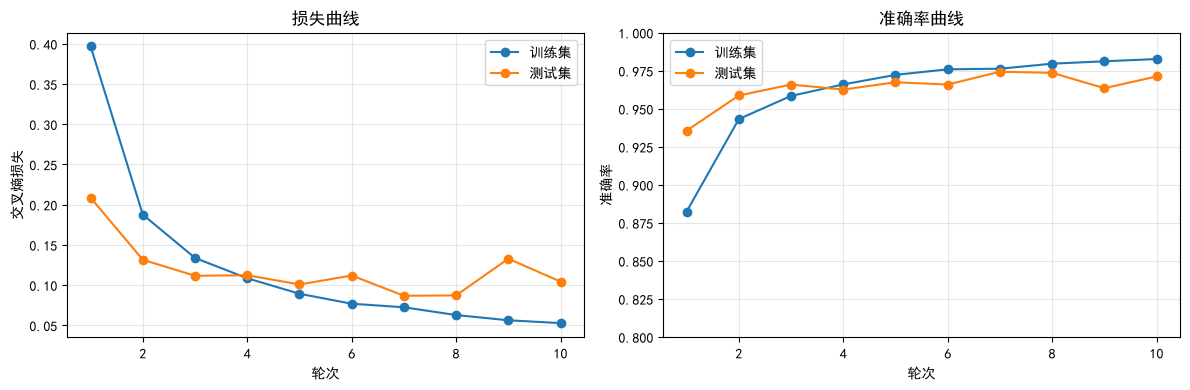

In [18]:
# 绘制损失和准确率曲线，可视化训练过程
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1,2, figsize=(12, 4))  # 创建一个1行2列的子图

# 绘制训练和测试损失曲线
axes[0].plot(epochs, history['train_loss'], marker = 'o', label='训练集') # marker='o'表示在每个数据点上绘制一个圆形标记
axes[0].plot(epochs, history['test_loss'], marker = 'o', label='测试集') # 绘制测试损失曲线
axes[0].set_title('损失曲线')  # 设置子图标题
axes[0].set_xlabel('轮次')  # 设置x轴标签
axes[0].set_ylabel('交叉熵损失')  # 设置y轴标签
axes[0].legend()  # 显示图例
axes[0].grid(alpha=0.3)  # 显示网格，alpha=0.3表示网格线的透明度

# 绘制训练和测试准确率曲线
axes[1].plot(epochs, history['train_acc'], marker = 'o', label='训练集')  # 绘制训练准确率曲线
axes[1].plot(epochs, history['test_acc'], marker = 'o', label='测试集')  # 绘制测试准确率曲线
axes[1].set_title('准确率曲线')  # 设置子图标题
axes[1].set_xlabel('轮次')  # 设置x轴标签
axes[1].set_ylabel('准确率')  # 设置y轴标签
axes[1].set_ylim(0.8, 1)  # 设置y轴范围为0到1
axes[1].legend()  # 显示图例        
axes[1].grid(alpha=0.3)  # 显示网格，alpha=0.3表示网格线的透明度

plt.tight_layout()  # 自动调整子图间距
plt.show()  # 显示图像

## 测试集评估与混淆矩阵

混淆矩阵的行是真实类别，列是预测类别，主对角线的数值越大，代表该类别识别得越精准

最终测试损失: 0.1044, 最终测试准确率: 0.9712


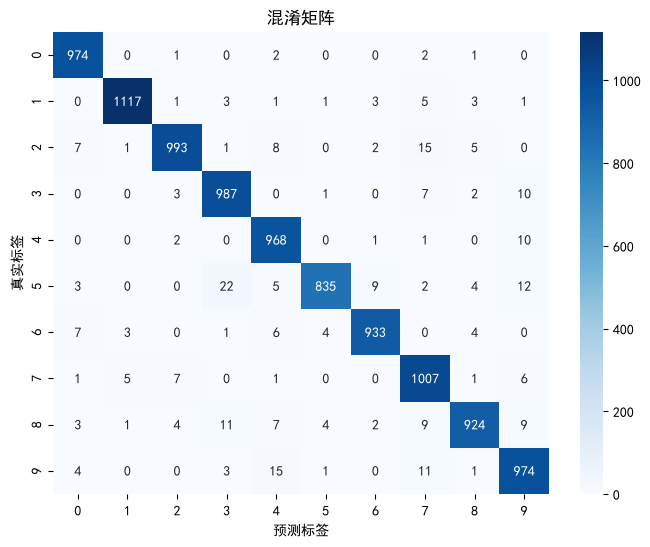

In [19]:
test_loss, test_acc = evaluate(model, test_loader)  # 在测试集上评估模型性能
print(f'最终测试损失: {test_loss:.4f}, 最终测试准确率: {test_acc:.4f}')  # 打印最终测试损失和准确率

model.eval()  # 设置模型为评估模式
all_labels = []  # 初始化一个空列表，用于存储所有的真实标签
all_preds = []  # 初始化一个空列表，用于存储所有的预测标签
with torch.no_grad():  # 在评估时不计算梯度
    for images, labels in test_loader:  # 遍历测试集数据加载器中的每个批次
        images, labels = images.to(device), labels.to(device)  # 将图像和标签移动到指定设备
        logits = model(images)  # 前向传播，获取模型输出
        preds = logits.argmax(dim=1)  # 获取预测结果，即最大概率对应的类别索引
        all_labels.extend(labels.cpu().numpy())  # 将真实标签添加到all_labels列表中，并将其从GPU移动到CPU
        all_preds.extend(preds.cpu().numpy())  # 将预测标签添加到all_preds列表中，并将其从GPU移动到CPU

# 计算混淆矩阵
cm = confusion_matrix(all_labels, all_preds)  # 计算混淆矩阵
plt.figure(figsize=(8, 6))  # 创建一个8x6英寸的图像
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # 使用Seaborn绘制混淆矩阵热力图，annot=True表示在每个单元格中显示数字，fmt='d'表示以整数格式显示
plt.title('混淆矩阵')  # 设置图像标题
plt.xlabel('预测标签')  # 设置x轴标签
plt.ylabel('真实标签')  # 设置y轴标签
plt.show()  # 显示图像


## 7.查看若干预测结果

标题中绿色表示预测正确，红色表示预测错误

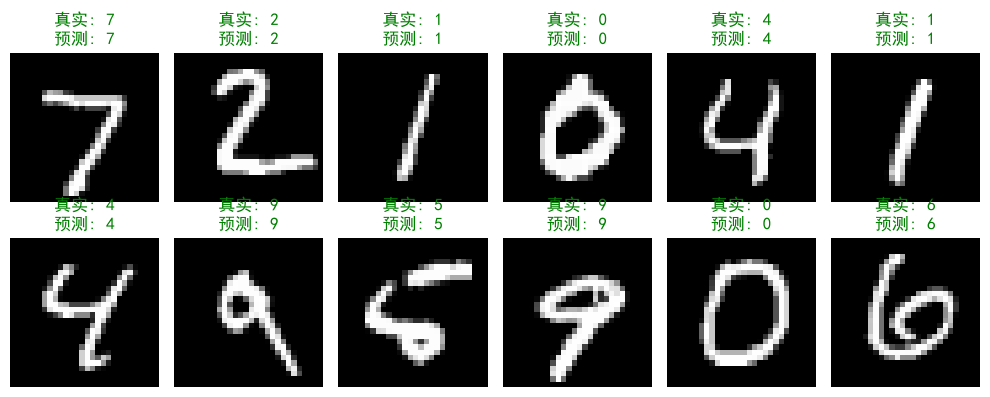

In [21]:
images, labels = next(iter(test_loader))  # 获取测试集中的一个批次数据
with torch.no_grad():  # 在评估时不计算梯度
    images, labels = images.to(device), labels.to(device)  # 将图像和标签

fig, axes = plt.subplots(2, 6, figsize=(10, 4))  # 创建一个2行6列的子图
for ax, image, true_label, pred_label in zip(axes.flat, images[:12], labels[:12], all_preds[:12]):
    # 为了显示，将归一化的数据还原到0~1
    ax.imshow(image.squeeze()*0.5+0.5, cmap='gray')  # 显示图像，squeeze()去掉多余的维度
    color = 'green' if true_label.item() == pred_label else 'red'  # 如果预测正确，标题为绿色，否则为红色
    ax.set_title(f'真实: {true_label.item()}\n预测: {pred_label}',color=color)  # 设置子图标题为真实标签和预测标签
    ax.axis('off')  # 关闭坐标轴显示
plt.tight_layout()  # 自动调整子图间距
plt.show()  # 显示图像